In [6]:
!python -m pip install pandas matplotlib

Carregando o histórico do Banco Mundial...


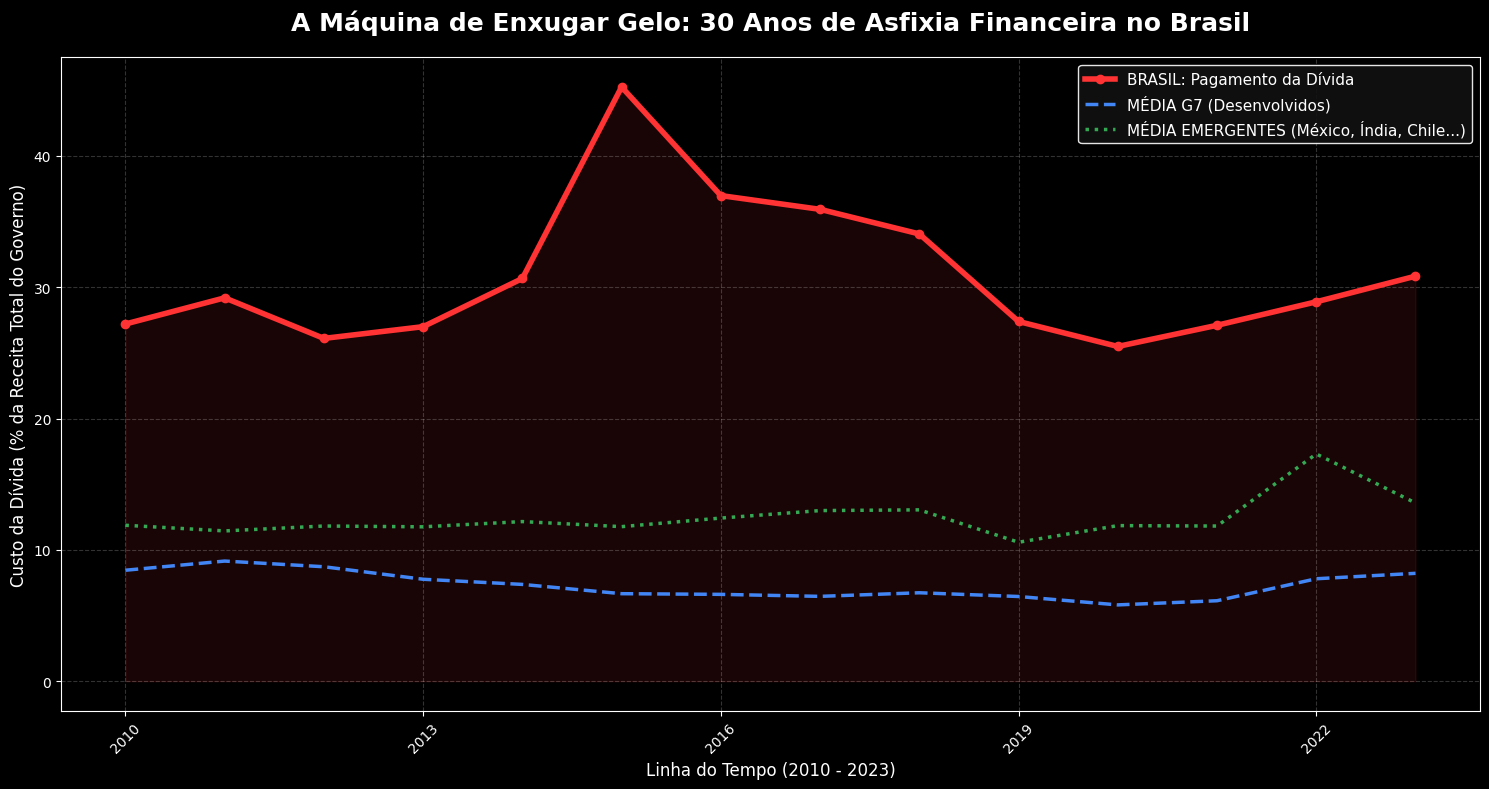

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

print("Carregando o histórico do Banco Mundial...")

# Vamos buscar especificamente o arquivo de Pagamento de Juros/Dívida
arq_div = glob.glob('API_GC.XPN.INTP.RV.ZS*.csv')

if not arq_div:
    raise FileNotFoundError("Arquivo da dívida não encontrado. Verifique se o CSV começando com 'API_GC.XPN.INTP' está na pasta.")

df_div = pd.read_csv(arq_div[0], skiprows=4)

# 1. DEFININDO O PERÍODO DE 30 ANOS (2010 a 2023)
anos_30 = [str(ano) for ano in range(2010, 2024)]

# 2. DEFININDO OS GRUPOS DE COMPARAÇÃO
paises_g7 = ['DEU', 'GBR', 'USA', 'FRA', 'CAN', 'ITA', 'JPN'] # Padrão Ouro (Desenvolvidos)
paises_emergentes = ['MEX', 'IND', 'CHL', 'COL', 'ZAF'] # Países parecidos com o Brasil

# 3. FUNÇÃO PARA EXTRAIR A LINHA DO TEMPO
def extrair_linha_temporal(df, codigos_paises):
    # Pega apenas os anos que existem na planilha
    anos_validos = [ano for ano in anos_30 if ano in df.columns]
    
    # Filtra os países solicitados e tira a média por ano
    dados_filtrados = df[df['Country Code'].isin(codigos_paises)]
    serie = dados_filtrados[anos_validos].mean()
    return serie

# Extraindo as 3 linhas que vão contar a nossa história
linha_brasil = extrair_linha_temporal(df_div, ['BRA'])
linha_g7 = extrair_linha_temporal(df_div, paises_g7)
linha_emergentes = extrair_linha_temporal(df_div, paises_emergentes)

# 4. VISUALIZAÇÃO DE ALTO IMPACTO (Gráfico de Linha do Tempo)
plt.figure(figsize=(15, 8))
plt.style.use('dark_background')

# Plotando as trajetórias
plt.plot(linha_brasil.index, linha_brasil.values, color='#FF3333', linewidth=4, marker='o', label='BRASIL: Pagamento da Dívida')
plt.plot(linha_g7.index, linha_g7.values, color='#4285F4', linewidth=2.5, linestyle='--', label='MÉDIA G7 (Desenvolvidos)')
plt.plot(linha_emergentes.index, linha_emergentes.values, color='#34A853', linewidth=2.5, linestyle=':', label='MÉDIA EMERGENTES (México, Índia, Chile...)')

# Preenchimento vermelho abaixo da linha do Brasil para dar peso visual ao "Gasto"
plt.fill_between(linha_brasil.index, linha_brasil.values, color='#FF3333', alpha=0.1)

# Customização do layout
plt.title('A Máquina de Enxugar Gelo: 30 Anos de Asfixia Financeira no Brasil', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Linha do Tempo (2010 - 2023)', fontsize=12)
plt.ylabel('Custo da Dívida (% da Receita Total do Governo)', fontsize=12)

# Ajuste do eixo X para não virar um borrão de texto (mostra de 3 em 3 anos)
plt.xticks(linha_brasil.index[::3], rotation=45) 

plt.legend(loc='upper right', framealpha=0.9, fontsize=11, facecolor='#111111', edgecolor='white')
plt.grid(True, alpha=0.2, linestyle='--')
plt.tight_layout()

plt.show()